您可以從 [Bookshop.org](https://bookshop.org/a/98697/9781098155438) 和 [Amazon](https://www.amazon.com/_/dp/1098155432?smid=ATVPDKIKX0DER&_encoding=UTF8&tag=oreilly20-20&_encoding=UTF8&tag=greenteapre01-20&linkCode=ur2&linkId=e2a529f94920295d27ec8a06e757dc7c&camp=1789&creative=9325) 訂購《Think Python 3e》的印刷版和電子書版本。

In [35]:
from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + str(local))
    return filename

download('https://github.com/AllenDowney/ThinkPython/raw/v3/thinkpython.py');
download('https://github.com/AllenDowney/ThinkPython/raw/v3/diagram.py');

import thinkpython

# 字典

本章介紹一種名為字典的內建型別。
它是 Python 最出色的功能之一——也是許多高效、優雅演算法的基礎建構元件。

我們將使用字典來計算書中獨特單詞的數量以及每個單詞出現的次數。
在練習中，我們將使用字典來解決單詞謎題。

## 字典是一種對應

**字典**類似於串列，但更通用。
在串列中，索引必須是整數；在字典中，它們可以是（幾乎）任何型別。
例如，假設我們建立一個數字詞彙的串列，如下所示。

In [37]:
lst = ['zero', 'one', 'two']

我們可以使用整數作為索引來取得對應的單詞。

In [38]:
lst[1]

'one'

但假設我們想要反向操作，查找一個單詞來取得對應的整數。
我們無法用串列做到這點，但可以用字典。
我們先建立一個空字典，並將它指派給 `numbers`。

In [39]:
numbers = {}
numbers

{}

大括號 `{}` 代表一個空字典。
要向字典中新增項目，我們將使用方括號。

In [40]:
numbers['zero'] = 0

這個指派動作將一個**項目**新增到字典中，它代表一個**鍵**和一個**值**的關聯。
在這個例子中，鍵是字串 `'zero'`，值是整數 `0`。
如果我們顯示字典，我們會看到它包含一個項目，其中包含一個鍵和一個值，用冒號 `:` 分隔。

In [41]:
numbers

{'zero': 0}

我們可以像這樣新增更多項目。

In [42]:
numbers['one'] = 1
numbers['two'] = 2
numbers

{'zero': 0, 'one': 1, 'two': 2}

現在字典包含三個項目。

要查找一個鍵並取得對應的值，我們使用方括號運算子。

In [43]:
numbers['two']

2

如果鍵不在字典中，我們會得到 `KeyError`。

In [44]:
%%expect KeyError
numbers['three']


KeyError: 'three'

`len` 函數也適用於字典；它會回傳項目的數量。

In [45]:
len(numbers)

3

在數學語言中，字典代表從鍵到值的**對應**，所以你也可以說每個鍵「對應到」一個值。
在這個例子中，每個數字詞彙都對應到相應的整數。

下圖顯示了 `numbers` 的狀態圖。

In [46]:
from diagram import make_dict, Binding, Value

d1 = make_dict(numbers, dy=-0.3, offsetx=0.37)
binding1 = Binding(Value('numbers'), d1)

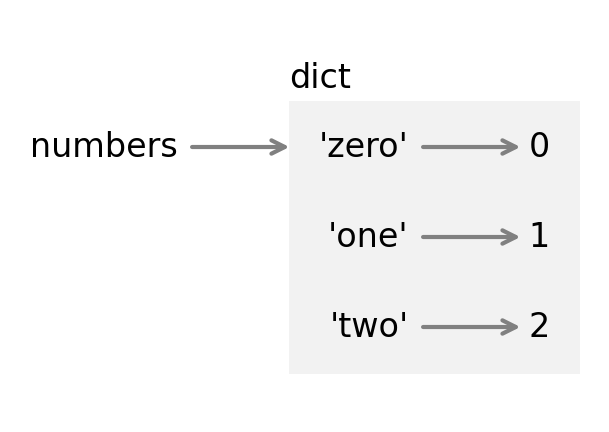

In [47]:
from diagram import diagram, adjust, Bbox

width, height, x, y = [1.83, 1.24, 0.49, 0.85]
ax = diagram(width, height)
bbox = binding1.draw(ax, x, y)
# adjust(x, y, bbox)

字典由一個方框表示，外部有「dict」字樣，內部有項目。
每個項目由一個鍵和一個指向值的箭頭表示。
引號表示這裡的鍵是字串，而不是變數名稱。

## 建立字典

在前一節中，我們建立了一個空字典，並使用方括號運算子一次新增一個項目。
相反地，我們也可以像這樣一次建立整個字典。

In [48]:
numbers = {'zero': 0, 'one': 1, 'two': 2}

每個項目由一個鍵和一個值組成，用冒號分隔。
項目之間用逗號分隔，並用大括號包圍。

建立字典的另一種方法是使用 `dict` 函數。
我們可以像這樣建立一個空字典。

In [49]:
empty = dict()
empty

{}

我們也可以像這樣建立字典的副本。

In [50]:
numbers_copy = dict(numbers)
numbers_copy

{'zero': 0, 'one': 1, 'two': 2}

在執行會修改字典的操作之前，建立副本通常很有用。

## in 運算子

`in` 運算子也適用於字典；它會告訴你某個東西是否作為*鍵*出現在字典中。

In [51]:
'one' in numbers

True

`in` 運算子*不會*檢查某個東西是否作為值出現。

In [52]:
1 in numbers

False

要檢查某個東西是否作為值出現在字典中，你可以使用 `values` 方法，它會回傳一個值的序列，然後使用 `in` 運算子。

In [53]:
1 in numbers.values()

True

Python 字典中的項目儲存在**雜湊表**中，這是一種組織資料的方式，具有一個顯著的特性：無論字典中有多少項目，`in` 運算子都花費大約相同的時間。
這使得撰寫一些極其高效的演算法成為可能。

In [54]:
download('https://raw.githubusercontent.com/AllenDowney/ThinkPython/v3/words.txt');

為了展示這一點，我們將比較兩種演算法來尋找單詞對，其中一個是另一個的倒轉——比如 `stressed` 和 `desserts`。
我們先讀取單詞清單。

In [55]:
word_list = open('words.txt').read().split()
len(word_list)

113783

這是前一章的 `reverse_word`。

In [56]:
def reverse_word(word):
    return ''.join(reversed(word))

以下函數迴圈遍歷清單中的單詞。
對於每一個，它將字母倒轉，然後檢查倒轉的單詞是否在單詞清單中。

In [57]:
def too_slow():
    count = 0
    for word in word_list:
        if reverse_word(word) in word_list:
            count += 1
    return count

這個函數需要超過一分鐘才能執行。
問題在於 `in` 運算子從頭開始一次檢查清單中的一個單詞。
如果它找不到想要的東西——這在大多數情況下都會發生——它必須搜尋到最後。

要測量函數需要多長時間，我們可以使用 `%time`，這是 Jupyter 的「內建魔法指令」之一。
這些指令不是 Python 語言的一部分，所以在其他開發環境中可能無法使用。

In [58]:
# %time too_slow()

而 `in` 運算子在迴圈內部，所以每個單詞都會執行一次。
由於清單中有超過 100,000 個單詞，而對於每個單詞我們都要檢查超過 100,000 個單詞，總比較次數大約是單詞數的平方——大約是 130 億次。

In [59]:
len(word_list)**2

12946571089

我們可以用字典讓這個函數快很多。
以下迴圈建立了一個包含單詞作為鍵的字典。

In [60]:
word_dict = {}
for word in word_list:
    word_dict[word] = 1

`word_dict` 中的值都是 `1`，但它們可以是任何東西，因為我們永遠不會查找它們——我們只會使用這個字典來檢查鍵是否存在。

現在這是前一個函數的版本，它將 `word_list` 替換為 `word_dict`。

In [61]:
def much_faster():
    count = 0
    for word in word_dict:
        if reverse_word(word) in word_dict:
            count += 1
    return count

這個函數需要不到百分之一秒，所以比前一個版本快了大約 10,000 倍。

一般來說，在串列中尋找元素所需的時間與串列的長度成正比。
在字典中尋找鍵所需的時間幾乎是常數——無論項目數量多少。

In [62]:
%time much_faster()

CPU times: user 59.4 ms, sys: 0 ns, total: 59.4 ms
Wall time: 59.1 ms


885

## 計數器的集合

假設你得到一個字串，你想要計算每個字母出現的次數。
字典是這項工作的好工具。
我們從一個空字典開始。

In [64]:
counter = {}

當我們迴圈遍歷字串中的字母時，假設我們第一次看到字母 `'a'`。
我們可以像這樣將它新增到字典中。

In [65]:
counter['a'] = 1

值 `1` 表示我們已經看到這個字母一次。
後來，如果我們再次看到同一個字母，我們可以像這樣增加計數器。

In [66]:
counter['a'] += 1

現在與 `'a'` 關聯的值是 `2`，因為我們已經看到這個字母兩次。

In [67]:
counter

{'a': 2}

以下函數使用這些功能來計算字串中每個字母出現的次數。

In [68]:
def value_counts(string):
    counter = {}
    for letter in string:
        if letter not in counter:
            counter[letter] = 1
        else:
            counter[letter] += 1
    return counter

在迴圈的每次執行中，如果 `letter` 不在字典中，我們建立一個新項目，鍵為 `letter`，值為 `1`。
如果 `letter` 已經在字典中，我們增加與 `letter` 關聯的值。

這是一個例子。

In [69]:
counter = value_counts('brontosaurus')
counter

{'b': 1, 'r': 2, 'o': 2, 'n': 1, 't': 1, 's': 2, 'a': 1, 'u': 2}

`counter` 中的項目顯示字母 `'b'` 出現一次，`'r'` 出現兩次，依此類推。

## 迴圈與字典

如果你在 `for` 陳述式中使用字典，它會遍歷字典的鍵。
為了展示這一點，讓我們建立一個計數 `'banana'` 中字母的字典。

In [70]:
counter = value_counts('banana')
counter

{'b': 1, 'a': 3, 'n': 2}

以下迴圈列印鍵，也就是字母。

In [71]:
for key in counter:
    print(key)

b
a
n


要列印值，我們可以使用 `values` 方法。

In [72]:
for value in counter.values():
    print(value)

1
3
2


要列印鍵和值，我們可以迴圈遍歷鍵並查找對應的值。

In [73]:
for key in counter:
    value = counter[key]
    print(key, value)

b 1
a 3
n 2


在下一章中，我們會看到一種更簡潔的方法來做同樣的事情。

## 串列與字典

你可以將串列作為值放入字典中。
例如，這是一個從數字 `4` 對應到四個字母串列的字典。

In [74]:
d = {4: ['r', 'o', 'u', 's']}
d

{4: ['r', 'o', 'u', 's']}

但你不能將串列作為鍵放入字典中。
如果我們嘗試，會發生以下情況。

In [76]:
%%expect TypeError
letters = list('abcd')
d[letters] = 4

TypeError: unhashable type: 'list'

我之前提到字典使用雜湊表，這意味著鍵必須是**可雜湊的**。

**雜湊**是一個函數，它接受一個值（任何類型）並回傳一個整數。
字典使用這些整數（稱為雜湊值）來儲存和查找鍵。

這個系統只有在鍵是不可變的情況下才能運作，所以它的雜湊值始終相同。
但如果鍵是可變的，它的雜湊值可能會改變，字典就無法正常運作。
這就是為什麼鍵必須是可雜湊的，以及為什麼像串列這樣的可變型別不可以的原因。

由於字典是可變的，它們也不能作為鍵使用。
但它們*可以*作為值使用。

## 累積串列

對於許多程式設計任務，在建立另一個串列或字典的同時迴圈遍歷一個串列或字典是很有用的。
作為例子，我們將迴圈遍歷 `word_dict` 中的單詞，並建立一個回文串列——也就是正向和反向拼寫相同的單詞，如「noon」和「rotator」。

在前一章中，其中一個練習要求你撰寫一個檢查單詞是否為回文的函數。
這是一個使用 `reverse_word` 的解決方案。

In [41]:
def is_palindrome(word):
    """Check if a word is a palindrome."""
    return reverse_word(word) == word

如果我們迴圈遍歷 `word_dict` 中的單詞，我們可以像這樣計算回文的數量。

In [42]:
count = 0

for word in word_dict:
    if is_palindrome(word):
        count +=1
        
count

91

到目前為止，這個模式很熟悉。

* 在迴圈開始之前，`count` 被初始化為 `0`。

* 在迴圈內部，如果 `word` 是回文，我們增加 `count`。

* 當迴圈結束時，`count` 包含回文的總數。

我們可以使用類似的模式來建立回文串列。

In [43]:
palindromes = []

for word in word_dict:
    if is_palindrome(word):
        palindromes.append(word)

palindromes[:10]

['aa', 'aba', 'aga', 'aha', 'ala', 'alula', 'ama', 'ana', 'anna', 'ava']

運作原理如下：

* 在迴圈開始之前，`palindromes` 被初始化為一個空串列。

* 在迴圈內部，如果 `word` 是回文，我們將它附加到 `palindromes` 的末尾。

* 當迴圈結束時，`palindromes` 是一個回文串列。

在這個迴圈中，`palindromes` 被用作**累積器**，這是一個在計算過程中收集或累積資料的變數。

現在假設我們只想選擇有七個或更多字母的回文。
我們可以迴圈遍歷 `palindromes` 並建立一個只包含長回文的新串列。

In [44]:
long_palindromes = []

for word in palindromes:
    if len(word) >= 7:
        long_palindromes.append(word)
        
long_palindromes

['deified', 'halalah', 'reifier', 'repaper', 'reviver', 'rotator', 'sememes']

像這樣迴圈遍歷串列，選擇一些元素並省略其他元素，稱為**過濾**。

## 備忘錄

如果你執行了[第六章](section_fibonacci)的 `fibonacci` 函數，你可能注意到提供的參數越大，函數執行時間越長。

In [45]:
def fibonacci(n):
    if n == 0:
        return 0
    
    if n == 1:
        return 1

    return fibonacci(n-1) + fibonacci(n-2)

此外，執行時間增加很快。
要了解原因，考慮以下圖表，它顯示了 `fibonacci` 當 `n=4` 時的**呼叫圖**：

In [46]:
from diagram import make_binding, Frame, Arrow

bindings = [make_binding('n', i) for i in range(5)]
frames = [Frame([binding]) for binding in bindings]

In [47]:
arrowprops = dict(arrowstyle="-", color='gray', alpha=0.5, ls='-', lw=0.5)

def left_arrow(ax, bbox1, bbox2):
    x = bbox1.xmin + 0.1
    y = bbox1.ymin
    dx = bbox2.xmax - x - 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

def right_arrow(ax, bbox1, bbox2):
    x = bbox1.xmax - 0.1
    y = bbox1.ymin
    dx = bbox2.xmin - x + 0.1
    dy = bbox2.ymax - y
    arrow = Arrow(dx=dx, dy=dy, arrowprops=arrowprops)
    return arrow.draw(ax, x, y)

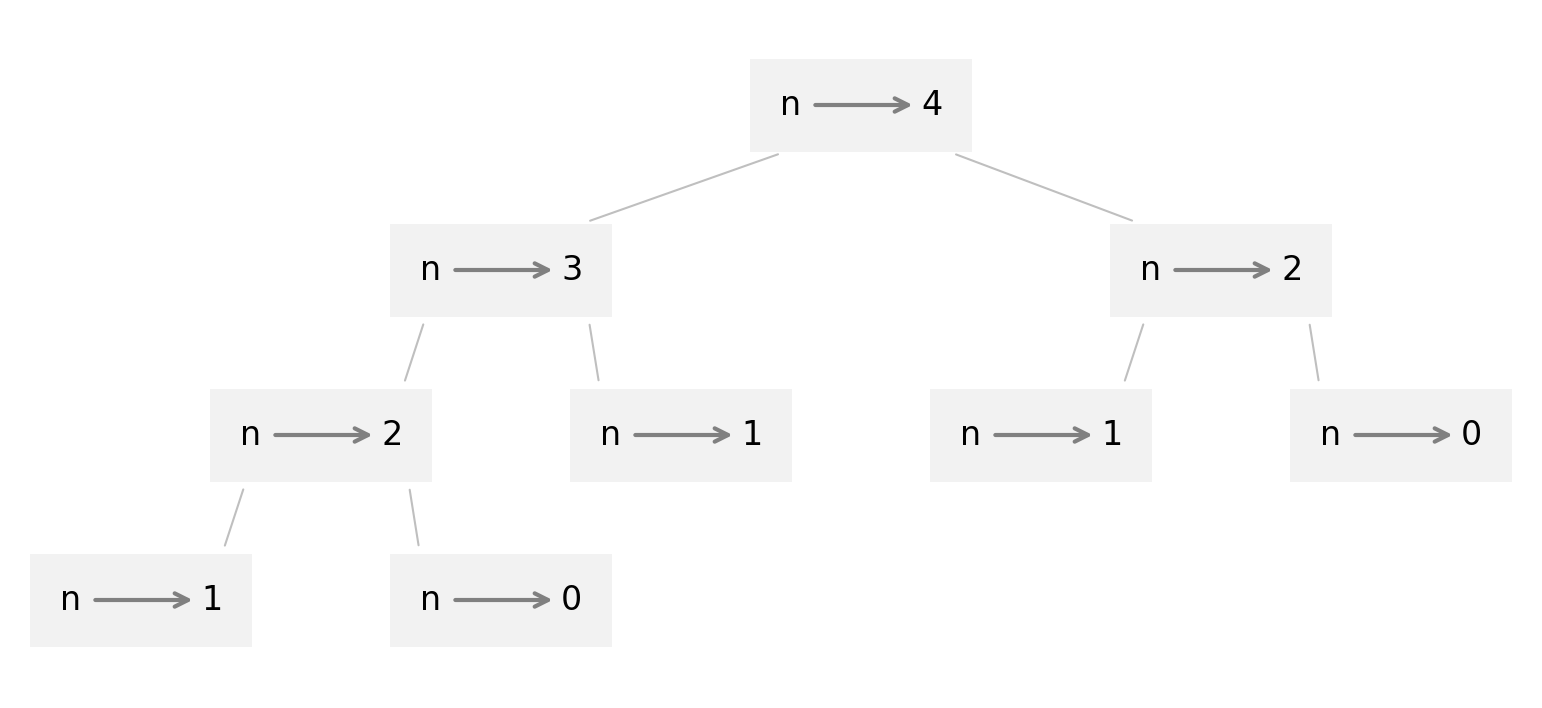

In [48]:
from diagram import diagram, adjust, Bbox

width, height, x, y = [4.94, 2.16, -1.03, 1.91]
ax = diagram(width, height)

dx = 0.6
dy = 0.55

bboxes = []
bboxes.append(frames[4].draw(ax, x+6*dx, y))

bboxes.append(frames[3].draw(ax, x+4*dx, y-dy))
bboxes.append(frames[2].draw(ax, x+8*dx, y-dy))

bboxes.append(frames[2].draw(ax, x+3*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+5*dx, y-2*dy))
bboxes.append(frames[1].draw(ax, x+7*dx, y-2*dy))
bboxes.append(frames[0].draw(ax, x+9*dx, y-2*dy))

bboxes.append(frames[1].draw(ax, x+2*dx, y-3*dy))
bboxes.append(frames[0].draw(ax, x+4*dx, y-3*dy))

left_arrow(ax, bboxes[0], bboxes[1])
left_arrow(ax, bboxes[1], bboxes[3])
left_arrow(ax, bboxes[3], bboxes[7])
left_arrow(ax, bboxes[2], bboxes[5])

right_arrow(ax, bboxes[0], bboxes[2])
right_arrow(ax, bboxes[1], bboxes[4])
right_arrow(ax, bboxes[2], bboxes[6])
right_arrow(ax, bboxes[3], bboxes[8])

bbox = Bbox.union(bboxes)
# adjust(x, y, bbox)

呼叫圖顯示一組函數框架，用線連接每個框架到它呼叫的函數框架。
在圖的頂部，`fibonacci` 當 `n=4` 時呼叫 `fibonacci` 當 `n=3` 和 `n=2` 時。
接著，`fibonacci` 當 `n=3` 時呼叫 `fibonacci` 當 `n=2` 和 `n=1` 時。依此類推。

計算 `fibonacci(0)` 和 `fibonacci(1)` 被呼叫了多少次。
這是問題的低效率解決方案，而且隨著參數變大會變得更糟。

一個解決方案是透過將已計算的值儲存在字典中來追蹤它們。
一個先前計算並儲存以供日後使用的值稱為**備忘錄**。
這是 `fibonacci` 的「備忘錄化」版本：

In [49]:
known = {0:0, 1:1}

def fibonacci_memo(n):
    if n in known:
        return known[n]

    res = fibonacci_memo(n-1) + fibonacci_memo(n-2)
    known[n] = res
    return res

`known` 是一個字典，追蹤我們已經知道的費波那契數列
它從兩個項目開始：`0` 對應到 `0`，`1` 對應到 `1`。

每當呼叫 `fibonacci_memo` 時，它會檢查 `known`。
如果結果已經在那裡，它可以立即回傳。
否則它必須計算新值，將它新增到字典中，然後回傳它。

比較這兩個函數，`fibonacci(40)` 需要大約 30 秒執行。
`fibonacci_memo(40)` 需要大約 30 微秒，所以快了一百萬倍。
在本章的筆記本中，你會看到這些測量結果的來源。

In [50]:
# %time fibonacci(40)

In [51]:
%time fibonacci_memo(40)

CPU times: user 13 µs, sys: 9 µs, total: 22 µs
Wall time: 24.3 µs


102334155

## 除錯

當你處理更大的資料集時，透過列印和手動檢查輸出來除錯可能變得笨重。以下是除錯大型資料集的一些建議：

1.  縮小輸入：如果可能的話，減少資料集的大小。例如，如果程式讀取文字檔案，從前 10 行開始，或者使用你能找到的最小例子。你可以直接編輯檔案，或者（更好的做法）修改程式，使其只讀取前 `n` 行。

    如果有錯誤，你可以將 `n` 減少到發生錯誤的最小值。
    當你找到並修正錯誤時，可以逐漸增加 `n`。

2. 檢查摘要和型別：不要列印和檢查整個資料集，考慮列印資料的摘要——例如，字典中項目的數量或數字串列的總和。

    執行時錯誤的常見原因是值的型別不正確。對於除錯這種錯誤，通常只需列印值的型別就足夠了。

3. 撰寫自我檢查：有時你可以撰寫程式碼來自動檢查錯誤。例如，如果你正在計算數字串列的平均值，你可以檢查結果是否不大於串列中的最大元素或小於最小元素。這被稱為「合理性檢查」，因為它檢測出「不合理」的結果。

    另一種檢查是比較兩種不同計算的結果，看看它們是否一致。這被稱為「一致性檢查」。

4. 格式化輸出：格式化除錯輸出可以讓發現錯誤變得更容易。我們在[第六章](section_debugging_factorial)中看到了一個例子。你可能會發現有用的另一個工具是 `pprint` 模組，它提供了一個 `pprint` 函數，以更易讀的格式顯示內建型別（`pprint` 代表「pretty print」）。

    再次強調，你花在建立基礎設施上的時間可以減少除錯所花的時間。

## 術語解釋

**字典：**
 包含鍵值對的物件，也稱為項目。

**項目：**
 在字典中，鍵值對的另一個名稱。

**鍵：**
 在字典中作為鍵值對第一部分出現的物件。

**值：**
 在字典中作為鍵值對第二部分出現的物件。這比我們之前使用「值」這個詞更具體。

**對應：**
  一種關係，其中一個集合的每個元素都對應到另一個集合的一個元素。

**雜湊表：**
鍵值對的集合，組織方式使我們能夠高效地查找鍵並找到其值。

**可雜湊的：**
 像整數、浮點數和字串這樣的不可變型別是可雜湊的。
 像串列和字典這樣的可變型別不是。

**雜湊函數：**
接受物件並計算用於在雜湊表中定位鍵的整數的函數。

**累積器：**
 在迴圈中用於相加或累積結果的變數。

**過濾：**
迴圈遍歷序列並選擇或省略元素。

**呼叫圖：**
顯示程式執行期間建立的每個框架的圖表，從每個呼叫者到每個被呼叫者都有箭頭。

**備忘錄：**
 一個已計算的值，儲存以避免不必要的未來計算。

## 練習

In [ ]:
# This cell tells Jupyter to provide detailed debugging information
# when a runtime error occurs. Run it before working on the exercises.

%xmode Verbose

### 詢問助理

在本章中，我說字典中的鍵必須是可雜湊的，並給出了簡短的解釋。如果你想要更多細節，請問虛擬助理：「為什麼 Python 字典中的鍵必須是可雜湊的？」

在[前面的章節](section_dictionary_in_operator)中，我們將單詞串列作為鍵儲存在字典中，以便能夠使用高效版本的 `in` 運算子。
我們也可以使用 `set` 來做同樣的事情，它是另一種內建資料型別。
請問虛擬助理：「如何從字串串列建立 Python 集合，並檢查字串是否是該集合的元素？」

### 練習

字典有一個名為 `get` 的方法，它接受一個鍵和一個預設值。
如果鍵出現在字典中，`get` 回傳對應的值；否則它回傳預設值。
例如，這是一個從字串中的字母對應到它們出現次數的字典。

In [52]:
counter = value_counts('brontosaurus')

如果我們查找在單詞中出現的字母，`get` 回傳它出現的次數。

In [53]:
counter.get('b', 0)

1

如果我們查找沒有出現的字母，我們得到預設值 `0`。

In [54]:
counter.get('c', 0)

0

使用 `get` 來撰寫更簡潔的 `value_counts` 版本。
你應該能夠去除 `if` 陳述式。

### 練習

你能想到的最長單詞是什麼，其中每個字母只出現一次？
讓我們看看能否找到比 `unpredictably` 更長的。

撰寫一個名為 `has_duplicates` 的函數，它接受一個序列——如串列或字串——作為參數，如果序列中有任何元素出現超過一次，則回傳 `True`。

為了幫助你開始，這是帶有文件測試的函數大綱。

In [55]:
def has_duplicates(t):
    """Check whether any element in a sequence appears more than once.
    
    >>> has_duplicates('banana')
    True
    >>> has_duplicates('ambidextrously')
    False
    >>> has_duplicates([1, 2, 2])
    True
    >>> has_duplicates([1, 2, 3])
    False
    """
    return None

In [56]:
# Solution

def has_duplicates(t):
    """Check whether any element in a sequence appears more than once.
    
    >>> has_duplicates('banana')
    True
    >>> has_duplicates('ambidextrously')
    False
    >>> has_duplicates([1, 2, 2])
    True
    >>> has_duplicates([1, 2, 3])
    False
    """
    d = {}
    for x in t:
        d[x] = True
    return len(d) < len(t)

你可以使用 `doctest` 來測試你的函數。

In [57]:
from doctest import run_docstring_examples

def run_doctests(func):
    run_docstring_examples(func, globals(), name=func.__name__)

run_doctests(has_duplicates)

你可以使用這個迴圈來尋找沒有重複字母的最長單詞。

In [58]:
no_repeats = []

for word in word_list:
    if len(word) > 12 and not has_duplicates(word):
        no_repeats.append(word)
        
no_repeats

['ambidextrously',
 'lycanthropies',
 'metalworkings',
 'multibranched',
 'unpredictably']

### 練習

撰寫一個名為 `find_repeats` 的函數，它接受一個從每個鍵對應到計數器的字典，如 `value_counts` 的結果。
它應該迴圈遍歷字典並回傳計數大於 `1` 的鍵串列。
你可以使用以下大綱開始。

In [59]:
def find_repeats(counter):
    """Makes a list of keys with values greater than 1.
    
    counter: dictionary that maps from keys to counts
    
    returns: list of keys
    """
    return []

In [60]:
# Solution

def find_repeats(counter):
    """Makes a list of keys with values greater than 1.
    
    counter: dictionary that maps from keys to counts
    
    returns: list of keys
    """
    repeats = []
    for key, count in counter.items():
        if count > 1:
            repeats.append(key)
    return repeats

你可以使用以下例子來測試你的程式碼。
首先，我們建立一個從字母對應到計數的字典。

In [61]:
counter1 = value_counts('banana')
counter1

{'b': 1, 'a': 3, 'n': 2}

`find_repeats` 的結果應該是 `['a', 'n']`。

In [62]:
repeats = find_repeats(counter1)
repeats

['a', 'n']

這是另一個從數字串列開始的例子。
結果應該是 `[1, 2]`。

In [63]:
counter1 = value_counts([1, 2, 3, 2, 1])
repeats = find_repeats(counter1)
repeats

[1, 2]

### 練習

假設你對兩個不同的單詞執行 `value_counts` 並將結果儲存在兩個字典中。

In [64]:
counter1 = value_counts('brontosaurus')
counter2 = value_counts('apatosaurus')

每個字典從一組字母對應到它們出現的次數。
撰寫一個名為 `add_counters` 的函數，它接受兩個這樣的字典並回傳一個包含所有字母以及它們在兩個單詞中出現總次數的新字典。

有很多方法可以解決這個問題。
一旦你有了可行的解決方案，考慮向虛擬助理詢問不同的解決方案。

In [65]:
# Solution

def add_counters(counter1, counter2):
    result = dict(counter1)
    for letter, count in counter2.items():
        result[letter] = result.get(letter, 0) + count
    return result

In [66]:
# Solution

add_counters(counter1, counter2)

{'b': 1, 'r': 3, 'o': 3, 'n': 1, 't': 2, 's': 4, 'a': 4, 'u': 4, 'p': 1}

### 練習

如果我們可以透過交替取字母將一個單詞分割成兩個單詞，這個單詞就是「交錯的」。
例如，「schooled」是一個交錯單詞，因為它可以分割成「shoe」和「cold」。

要從字串中選擇交替的字母，你可以使用有三個元件的切片運算子，指示從哪裡開始、在哪裡停止，以及字母之間的「步長」。

在以下切片中，第一個元件是 `0`，所以我們從第一個字母開始。
第二個元件是 `None`，表示我們應該一直到字串的末尾。
第三個元件是 `2`，所以我們選擇的字母之間有兩個步長。

In [67]:
word = 'schooled'
first = word[0:None:2]
first

'shoe'

不提供 `None` 作為第二個元件，我們可以完全省略它來達到相同的效果。
例如，以下切片選擇交替的字母，從第二個字母開始。

In [68]:
second = word[1::2]
second

'cold'

撰寫一個名為 `is_interlocking` 的函數，它接受一個單詞作為參數，如果它可以分割成兩個交錯單詞，則回傳 `True`。

In [69]:
# Solution

def is_interlocking(word):
    first = word[0::2]
    second = word[1::2]
    return first in word_dict and second in word_dict

你可以使用以下迴圈來尋找單詞清單中的交錯單詞。

In [70]:
for word in word_list:
    if len(word) >= 8 and is_interlocking(word):
        first = word[0::2]
        second = word[1::2]
        print(word, first, second)

adroitly aril doty
agrarians arras gain
alienees aine lees
arrestee arse rete
arrestees arses rete
ballooned blond aloe
barmaids brad amis
baudrons burn ados
beakless bals ekes
beamless bals emes
bloodred bode lord
blueness buns lees
booklets bolt okes
burseeds bred uses
calliope clip aloe
calliopes clips aloe
cellules clue ells
cheerier cere heir
colludes clue olds
cookless cols okes
coolness cons oles
countess cuts ones
couplets cult opes
dainties dite anis
doorless dols ores
dourness duns ores
fairness fins ares
fleetest fets leet
fleetness fetes lens
foulness funs oles
freeness fens rees
friended fine redd
furrings frig urns
goalless gals oles
greeniest genet reis
greyness gens ryes
grounded gone rudd
hooklets holt okes
ignitron into girn
isleless ills sees
mailless mils ales
moonless mols ones
moonlets molt ones
moonsets most ones
neutrals nurl etas
oghamist ohms gait
parietes pree aits
peakless pals ekes
plainness panes lins
playless pals lyes
pleonasm pens loam
poorness pons ore

[Think Python: 3rd Edition](https://allendowney.github.io/ThinkPython/index.html)

版權所有 2024 [Allen B. Downey](https://allendowney.com)

程式碼授權：[MIT License](https://mit-license.org/)

文字授權：[Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International](https://creativecommons.org/licenses/by-nc-sa/4.0/)